# Part 0: Load in libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sbn
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
import localcider
from localcider.sequenceParameters import SequenceParameters
import re
import math
import scipy
from scipy.stats import ks_2samp
from matplotlib.patches import Rectangle
import pathlib
from matplotlib import font_manager
from statannot import add_stat_annotation
from scipy.stats import mannwhitneyu

# Setup the fonts
fonts_path = pathlib.Path.home().joinpath('fonts') # i.e. `~/fonts` (update as needed)
font_filename = 'ARIAL.TTF'
font_path = fonts_path.joinpath(font_filename)
print(font_path)

font_manager.fontManager.addfont(str(font_path))
prop = font_manager.FontProperties(fname=font_path)

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = prop.get_name()
plt.rcParams['pdf.fonttype'] = 42 # Makes text editiable
plt.rcParams['ps.fonttype'] = 42

COLOR_MAP = dict()
COLOR_MAP['A']         = '#8c8c8c'
COLOR_MAP['CHNQST']    = '#077a15'
COLOR_MAP['DE']        = '#e23a36'
COLOR_MAP['FWY']       = '#f58220'
COLOR_MAP['G']         = '#86bd8d'
COLOR_MAP['ILMV']      = '#231f20'
COLOR_MAP['KR']        = '#1725c2'
COLOR_MAP['P']         = '#c25fc9'


# Using the global color map, we convert the colormap of amino acid
# groups, to a map against individual amino acids. This
# serves as our internal color map which is used for styling.
aacolor_map=dict()
for amino_acids in COLOR_MAP:
    for amino_acid in amino_acids:
        aacolor_map[amino_acid] = COLOR_MAP[amino_acids]

/home/compute/kiersten.ruff/fonts/ARIAL.TTF


# Part 1: Load in data

## 1.1 - Load in NARDINI+ data

In [3]:
df=pd.read_excel('../Run_NARDINI+/excel_zscore_files/catsper1_n_terminals_patterning_compositional_feature_zscores.xlsx')
print(df)

colnamelist=list(df.columns)
allfeatlist=colnamelist[6:]
allspecieslist=df['Genes'].tolist()
print(allfeatlist)

    Unnamed: 0                          Genes                        Uniprot  \
0            0                   Mus musculus                   Mus musculus   
1            1                Cavia porcellus                Cavia porcellus   
2            2                  Octodon degus                  Octodon degus   
3            3          Heterocephalus glaber          Heterocephalus glaber   
4            4             Lipotes vexillifer             Lipotes vexillifer   
5            5          Monodelphis domestica          Monodelphis domestica   
6            6            Pelodiscus sinensis            Pelodiscus sinensis   
7            7          Elephantulus edwardii          Elephantulus edwardii   
8            8               Vombatus ursinus               Vombatus ursinus   
9            9         Apostichopus japonicus         Apostichopus japonicus   
10          10       Capricornis sumatraensis       Capricornis sumatraensis   
11          11         Phascolarctos cin

## 1.2 - Load in fertilization temperature data

In [4]:
tables1df=pd.read_excel('data/Table_1.xlsx')
tempspeciesname=[]
for s in range(0,len(tables1df)):
    tempspeciesname.append(tables1df['Species name'].tolist()[s].strip())
#print(tables1df.columns.tolist())
templist=tables1df['Temperature'].tolist()
coldcoff=23
warmcoff=35
print(tables1df)

# Get cold fertilization group
tmpdf=tables1df[tables1df['Temperature']<=coldcoff]
#print(tmpdf)

tmplist=tmpdf['Species name'].tolist()
lftspecies = [item.strip() for item in tmplist]
lftdf=df[df['Genes'].isin(lftspecies)]
lftspecieslist=lftdf['Genes'].tolist()
print(lftdf)

# Get intermediate fertilization group
tmpdf=tables1df[(tables1df['Temperature']>coldcoff) & (tables1df['Temperature']<warmcoff)]
#print(tmpdf)

tmplist=tmpdf['Species name'].tolist()
iftspecies = [item.strip() for item in tmplist]
iftdf=df[df['Genes'].isin(iftspecies)]
iftspecieslist=iftdf['Genes'].tolist()
print(iftdf)

# Get warm fertilization group
tmpdf=tables1df[(tables1df['Temperature']>=warmcoff)]
#print(tmpdf)

tmplist=tmpdf['Species name'].tolist()
hftspecies = [item.strip() for item in tmplist]
hftdf=df[df['Genes'].isin(hftspecies)]
hftspecieslist=hftdf['Genes'].tolist()
print(hftdf)

   Unnamed: 0                    Species name                     Common name  \
0          1             Oncorhynchus mykiss                   Rainbow trout    
1          2                     Salmo salar                 Atlantic salmon    
2          3          Lamellibrachia satsuma               Satsuma tube worm    
3          4              Ciona intestinalis                      Sea squirt    
4          5   Strongylocentrotus purpuratus               Purple sea urchin    
5          6          Apostichopus japonicus           Japanese sea cucumber    
6          7          Nematostella vectensis             Starlet sea anemone    
7          8             Paramuricea clavata           Red gorgonian sea fan    
8          9               Orchesella cincta                      Springtail    
9         10           Stylophora pistillata        Smooth cauliflower coral    
10        11                 Lingula anatina              Lingula brachiopod    
11        12             Acr

## 1.3 - Add fertilization temperature to grammar data

In [5]:
print(tempspeciesname)
alltemplist=[]
for s in range(0,len(allspecieslist)):
    idx=tempspeciesname.index(allspecieslist[s])
    alltemplist.append(templist[idx])
    
print(alltemplist)

tempgrammardf=df.copy()
tempgrammardf['Temperature']=alltemplist
tempgrammardf=tempgrammardf.sort_values(by=['Temperature','Frac H'])
print(tempgrammardf)

['Oncorhynchus mykiss', 'Salmo salar', 'Lamellibrachia satsuma', 'Ciona intestinalis', 'Strongylocentrotus purpuratus', 'Apostichopus japonicus', 'Nematostella vectensis', 'Paramuricea clavata', 'Orchesella cincta', 'Stylophora pistillata', 'Lingula anatina', 'Acropora digitifera', 'Acropora millepora', 'Pelodiscus sinensis', 'Alligator mississippiensis', 'Heterocephalus glaber', 'Ornithorhynchus anatinus', 'Podarcis muralis', 'Vombatus ursinus', 'Monodelphis domestica', 'Varanus komodoensis', 'Elephantulus edwardii', 'Sarcophilus harrisii', 'Fukomys damarensis', 'Phascolarctos cinereus', 'Lipotes vexillifer', 'Loxodonta africana', 'Notamacropus eugenii', 'Tursiops truncatus', 'Homo sapiens', 'Mus musculus', 'Macaca mulatta', 'Mirounga angustirostris', 'Physeter macrocephalus', 'Myotis lucifugus', 'Equus caballus', 'Ursus arctos', 'Lontra canadensis', 'Octodon degus', 'Bos taurus', 'Canis lupus familiaris', 'Capra hircus', 'Capricornis sumatraensis', 'Oryctolagus cuniculus', 'Sus scrof

# Part 2: Analyze Data

## 2.1 - Determine which features have different distributions

In [29]:
myfeat=allfeatlist
#myfeat=['Frac H','Hydrophobicity','FCR','Disorder Promoting']
number_slider=0
whichcomps=['Warm-Intermediate','Warm-Cold','Intermediate-Cold']
pvallkslog=np.zeros((len(whichcomps),len(myfeat)))

# Get Warm vs Intermediate
for p in range(0,len(myfeat)):

    userzvec=hftdf[myfeat[p]].tolist()

    idromezvec=iftdf[myfeat[p]].tolist()

    tmp=ks_2samp(idromezvec, userzvec, alternative='two-sided', mode='auto')
    #tmp=mannwhitneyu(idromezvec, userzvec, alternative='two-sided')
    #print(tmp)

    if tmp.pvalue<0.05 and np.mean(userzvec)>=np.mean(idromezvec):# and np.mean(userzvec)>=number_slider:
        if tmp.pvalue==0:
            pvallkslog[0,p]=1000
        else:
            pvallkslog[0,p]=-1*math.log10(tmp.pvalue)
        #print(myfeat[p])
        #print(pvallkslog[0,p])
        #plt.figure()
        #sbn.ecdfplot(userzvec,label='User IDRs')
        #sbn.ecdfplot(idromezvec,label='Rest of IDRome')
        #plt.title(myfeat[p])
    elif tmp.pvalue<0.05 and np.mean(userzvec)<np.mean(idromezvec):# and np.mean(userzvec)<=number_slider:
        if tmp.pvalue==0:
            pvallkslog[0,p]=-1000
        else:
            pvallkslog[0,p]=math.log10(tmp.pvalue)
        #print(myfeat[p])
        #print(pvallkslog[0,p])
        #plt.figure()
        #sbn.ecdfplot(userzvec,label='User IDRs')
        #sbn.ecdfplot(idromezvec,label='Rest of IDRome')
        #plt.title(myfeat[p])
    else:
        #print(myfeat[p])
        #print(pvallkslog[p])
        pvallkslog[0,p]=0
        
        
# Get Warm vs Cold
for p in range(0,len(myfeat)):

    userzvec=hftdf[myfeat[p]].tolist()

    idromezvec=lftdf[myfeat[p]].tolist()

    tmp=ks_2samp(idromezvec, userzvec, alternative='two-sided', mode='auto')
    #tmp=mannwhitneyu(idromezvec, userzvec, alternative='two-sided')
    #print(tmp)

    if tmp.pvalue<0.05 and np.mean(userzvec)>=np.mean(idromezvec):# and np.mean(userzvec)>=number_slider:
        if tmp.pvalue==0:
            pvallkslog[1,p]=1000
        else:
            pvallkslog[1,p]=-1*math.log10(tmp.pvalue)
        #print(myfeat[p])
        #print(pvallkslog[1,p])
        #plt.figure()
        #sbn.ecdfplot(userzvec,label='User IDRs')
        #sbn.ecdfplot(idromezvec,label='Rest of IDRome')
        #plt.title(myfeat[p])
    elif tmp.pvalue<0.05 and np.mean(userzvec)<np.mean(idromezvec):# and np.mean(userzvec)<=number_slider:
        if tmp.pvalue==0:
            pvallkslog[1,p]=-1000
        else:
            pvallkslog[1,p]=math.log10(tmp.pvalue)
        #print(myfeat[p])
        #print(pvallkslog[1,p])
        #plt.figure()
        #sbn.ecdfplot(userzvec,label='User IDRs')
        #sbn.ecdfplot(idromezvec,label='Rest of IDRome')
        #plt.title(myfeat[p])
    else:
        #print(myfeat[p])
        #print(pvallkslog[p])
        pvallkslog[1,p]=0
        
        
# Get Intermediate vs Cold
for p in range(0,len(myfeat)):

    userzvec=iftdf[myfeat[p]].tolist()

    idromezvec=lftdf[myfeat[p]].tolist()

    tmp=ks_2samp(idromezvec, userzvec, alternative='two-sided', mode='auto')
    #tmp=mannwhitneyu(idromezvec, userzvec, alternative='two-sided')
    #print(tmp)

    if tmp.pvalue<0.05 and np.mean(userzvec)>=np.mean(idromezvec):# and np.mean(userzvec)>=number_slider:
        if tmp.pvalue==0:
            pvallkslog[2,p]=1000
        else:
            pvallkslog[2,p]=-1*math.log10(tmp.pvalue)
        #print(myfeat[p])
        #print(pvallkslog[2,p])
        #plt.figure()
        #sbn.ecdfplot(userzvec,label='User IDRs')
        #sbn.ecdfplot(idromezvec,label='Rest of IDRome')
        #plt.title(myfeat[p])
    elif tmp.pvalue<0.05 and np.mean(userzvec)<np.mean(idromezvec):# and np.mean(userzvec)<=number_slider:
        if tmp.pvalue==0:
            pvallkslog[2,p]=-1000
        else:
            pvallkslog[2,p]=math.log10(tmp.pvalue)
        #print(myfeat[p])
        #print(pvallkslog[2,p])
        #plt.figure()
        #sbn.ecdfplot(userzvec,label='User IDRs')
        #sbn.ecdfplot(idromezvec,label='Rest of IDRome')
        #plt.title(myfeat[p])
    else:
        #print(myfeat[p])
        #print(pvallkslog[p])
        pvallkslog[2,p]=0
        
pvaldf=pd.DataFrame(pvallkslog.T,columns=whichcomps)
pvaldf.insert(0, 'Feature', myfeat)
print(pvaldf)

pvalno0df=pvaldf[(pvaldf.select_dtypes(include='number') != 0).any(axis=1)]

pvalno0df=pvalno0df.sort_values(by=['Warm-Intermediate','Warm-Cold','Intermediate-Cold'],ascending=False)
print(pvalno0df)
print(len(pvalno0df))

    Feature  Warm-Intermediate  Warm-Cold  Intermediate-Cold
0   pol-pol                0.0   0.000000                0.0
1   pol-hyd                0.0   0.000000                0.0
2   pol-pos                0.0   0.000000                0.0
3   pol-neg                0.0   0.000000                0.0
4   pol-aro                0.0   0.000000                0.0
..      ...                ...        ...                ...
85  S Patch                0.0   3.606972                0.0
86  T Patch                0.0   0.000000                0.0
87  V Patch                0.0   0.000000                0.0
88  Y Patch                0.0   0.000000                0.0
89  RG Frac                0.0   0.000000                0.0

[90 rows x 4 columns]
                 Feature  Warm-Intermediate  Warm-Cold  Intermediate-Cold
42                Frac H           6.149881   3.181003           0.000000
58            Frac Polar           3.028102   3.606972           0.000000
76               H Patc

## 2.2 - Plot which features have different distributions as heatmap

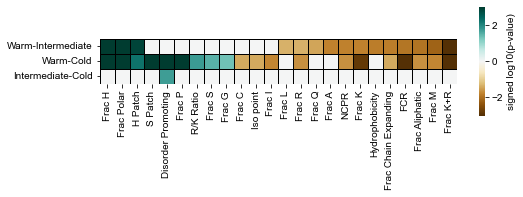

In [11]:
myfeatno0=pvalno0df['Feature'].tolist()

plt.figure(figsize=(len(myfeatno0)/3,2))
sbn.heatmap(pvalno0df.iloc[:,1:].T,cmap='BrBG',vmin=-3,vmax=3,square=True,linewidth=1,linecolor='k',cbar_kws={"label": "signed log10(p-value)"})

plt.xticks(np.arange(0.5,len(myfeatno0)),myfeatno0,rotation=90)
plt.yticks(np.arange(0.5,3),['Warm-Intermediate','Warm-Cold','Intermediate-Cold'],rotation=0)
print('')

#pvalno0df.to_excel('../Excel_files_for_plotting/Fig_2c.xlsx')
#print(pvalno0df)

#plt.savefig('figures/2026_06/ks_heatmap_compare_fertilization_temperatures_'+str(len(subfeats))+'_features.pdf', transparent=True, bbox_inches = "tight")
#plt.savefig('figures/2026_06/ks_heatmap_compare_fertilization_temperatures_'+str(len(subfeats))+'_features_BrBG.pdf', transparent=True, bbox_inches = "tight")


## 2.3 - Plot boxplot of selected features

8.796310023798059
-1.433611032266368
-0.6239993332476815
0.4666445814125553


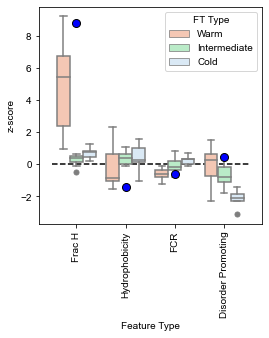

In [22]:
#subfeats=myfeatno0
subfeats=['Frac H','Hydrophobicity','FCR','Disorder Promoting']

subfeatval=[]
subfeattype=[]
subfttype=[]
subspecies=[]
for f in range(0,len(subfeats)):
    for s in range(0,len(df)):
        subfeattype.append(subfeats[f])
        subfeatval.append(df[subfeats[f]].tolist()[s])
        subspecies.append(df['Genes'].tolist()[s])
        if df['Genes'].tolist()[s] in lftspecieslist:
            subfttype.append('Cold')
        elif df['Genes'].tolist()[s] in iftspecieslist:
            subfttype.append('Intermediate')
        elif df['Genes'].tolist()[s] in hftspecieslist:
            subfttype.append('Warm')
            
#         if df['Genes'].tolist()[s] in lftspecieslist or df['Genes'].tolist()[s] in iftspecieslist:
#             subfeattype.append(subfeats[f])
#             subfeatval.append(df[subfeats[f]].tolist()[s])
#             subfttype.append('Low-Intermediate')
            
        
        
subfeatdf=pd.DataFrame()
subfeatdf['Species']=subspecies
subfeatdf['z-score']=subfeatval
subfeatdf['Feature Type']=subfeattype
subfeatdf['FT Type']=subfttype

#mypalette={'Warm':'#fbc2a9', 'Intermediate':'#badfbd', 'Cold':'#d6e9f8'} #CMYK
mypalette={'Warm':'#ffc3a9', 'Intermediate':'#b2f3c4', 'Cold':'#d5eaf9'} #RGB

#mypalettescatt={'Warm':'#c1c0c1', 'Intermediate':'#c1c0c1', 'Cold':'#c1c0c1'}

plt.figure(figsize=(len(subfeats),4))
flier_dict = dict(marker='o')

ax=sbn.boxplot(data=subfeatdf,x='Feature Type',y='z-score',hue='FT Type',palette=mypalette,flierprops=flier_dict)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

#subfeatdf.to_excel('../Excel_files_for_plotting/Fig_2b.xlsx')
#print(subfeatdf)

# If want scatter of points
#sbn.stripplot(data=subfeatdf,x='Feature Type',y='z-score',hue='FT Type', palette=mypalettescatt, dodge=True, alpha=0.5, linewidth=0.5, edgecolor='black', jitter=0.2)

# Plot naked mole rat values
currspecies='Heterocephalus glaber'
idx=allspecieslist.index(currspecies)
tmpdf=df.iloc[idx]
for s in range(0,len(subfeats)):
    plt.plot(s,tmpdf[subfeats[s]],'o',color='#0000ff',markeredgecolor='k',markersize=8)
    print(tmpdf[subfeats[s]])
    
#tdf=subfeatdf[subfeatdf['Species']=='Heterocephalus glaber']
#print(tdf)
    
plt.plot([-0.5,3.5],[0,0],'--k',zorder=-1)
#plt.savefig('figures/2026_06/z-score_boxplots_by_fertilization_temperatures_'+str(len(subfeats))+'_features.pdf', transparent=True, bbox_inches = "tight")

#print(df[['Genes','Frac H']])

## 2.4 - Plot feature heatmap by species

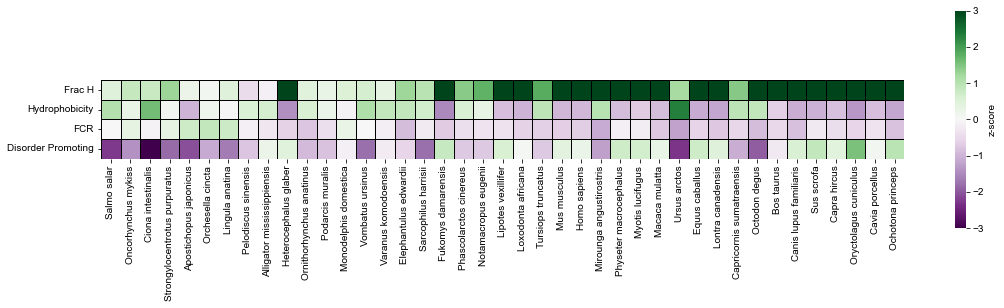

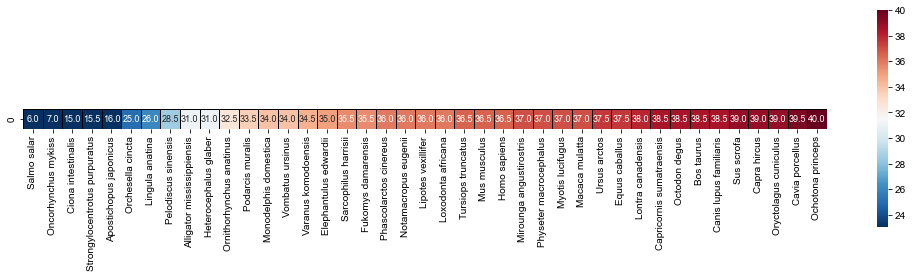

In [24]:
#subfeats=myfeatno0
subfeats=['Frac H','Hydrophobicity','FCR','Disorder Promoting']

plt.figure(figsize=(18, len(subfeats)))
sbn.heatmap(tempgrammardf[subfeats].T,cmap='PRGn',vmin=-3,vmax=3,linewidth=1,linecolor='k',square=True,cbar_kws={"label": "z-score"})
plt.xticks(np.arange(0.5,len(tempgrammardf)),tempgrammardf['Genes'].tolist(),rotation=90)

#plt.savefig('figures/2026_06/z-score_heatmap_sorted_by_fertilization_temperatures_'+str(len(subfeats))+'_features.pdf', transparent=True, bbox_inches = "tight")

plt.figure(figsize=(18, len(subfeats)))
#sbn.heatmap([tempgrammardf['Temperature'].T],cmap='RdBu_r',vmin=coldcoff,vmax=40,linewidth=1,linecolor='k',square=True,annot=True,annot_kws={"size": 12})
sbn.heatmap([tempgrammardf['Temperature'].T],cmap='RdBu_r',vmin=coldcoff,vmax=40,linewidth=1,linecolor='k',square=True,annot=True,annot_kws={"size": 9},fmt='.1f')

plt.xticks(np.arange(0.5,len(tempgrammardf)),tempgrammardf['Genes'].tolist(),rotation=90)
print('')

#subfeatdf.to_excel('../Excel_files_for_plotting/Fig_2a.xlsx')
#print(tempgrammardf)

#plt.savefig('figures/2026_06/temperature_heatmap_sorted_by_fertilization_temperatures.pdf', transparent=True, bbox_inches = "tight")
#plt.savefig('figures/2026_06/temperature_heatmap_sorted_by_fertilization_temperatures_decimal.pdf', transparent=True, bbox_inches = "tight")
